# Experiment: Price Tag OCR Baseline

Базовый исследовательский pipeline для извлечения полей ценника из кропов `track_*` без детектора/трекинга.


## 1. Imports and paths

Инициализируем зависимости, пути проекта и директории результатов.


In [1]:
print('jdsnv')

jdsnv


In [14]:
from __future__ import annotations

import json
import math
import os
import re
import traceback
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any
from urllib.parse import parse_qsl, urlparse

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/home/jupyter/project")).resolve()

_default_dataset_candidates = [
    Path("/home/jupyter/project/top_crops/top_crops"),
    Path("/home/jupyter/project/top_crops"),
    PROJECT_ROOT / "top_crops" / "top_crops",
    PROJECT_ROOT / "top_crops",
]

if os.getenv("DATASET_ROOT"):
    DATASET_ROOT = Path(os.getenv("DATASET_ROOT")).resolve()
else:
    DATASET_ROOT = None
    for _cand in _default_dataset_candidates:
        if _cand.exists():
            DATASET_ROOT = _cand.resolve()
            break
    if DATASET_ROOT is None:
        DATASET_ROOT = _default_dataset_candidates[0].resolve()

TASK_PATH = Path(os.getenv("TASK_PATH", str(PROJECT_ROOT / "lenta_tech_life_hack_text.md"))).resolve()

OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", str(PROJECT_ROOT / "outputs_ocr_baseline"))).resolve()
DEBUG_DIR = OUTPUT_DIR / "debug"
OUTPUT_CSV = Path(os.getenv("OUTPUT_CSV", str(OUTPUT_DIR / "result.csv"))).resolve()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"TASK_PATH: {TASK_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"DEBUG_DIR: {DEBUG_DIR}")
print(f"OUTPUT_CSV: {OUTPUT_CSV}")

if not DATASET_ROOT.exists():
    print(f"[WARN] DATASET_ROOT does not exist yet: {DATASET_ROOT}")



PROJECT_ROOT: /home/jupyter/project
DATASET_ROOT: /home/jupyter/project/top_crops/top_crops
TASK_PATH: /home/jupyter/project/lenta_tech_life_hack_text.md
OUTPUT_DIR: /home/jupyter/project/outputs_ocr_baseline
DEBUG_DIR: /home/jupyter/project/outputs_ocr_baseline/debug
OUTPUT_CSV: /home/jupyter/project/outputs_ocr_baseline/result.csv


In [7]:
!rm -rf /home/jupyter/project/top_crops/__MACOSX

## 2. Read task description

Читаем исходное описание кейса, чтобы ноутбук был явно связан с постановкой задачи.


## 3. Dependencies and graceful fallback

Ниже команды для **однократной установки** зависимостей в Kaggle/Colab до запуска ноутбука.
После установки сделайте `Restart & clear cell outputs` (не `Factory reset`) и запускайте `Run all`.

```bash
python -m pip install -U pip uv
apt-get update && apt-get install -y libzbar0
uv pip install --system --break-system-packages   numpy==1.26.4 pandas==2.2.3 matplotlib==3.8.4 tqdm==4.67.1   opencv-python==4.10.0.84 opencv-contrib-python==4.10.0.84   pillow==10.4.0 pyzbar==0.1.9   paddlepaddle==3.2.0 paddleocr==3.2.0
```

Если `paddleocr`/`pyzbar` не установлены, ноутбук не падает: OCR/QR просто перейдут в fallback-режим.


In [17]:
import sys, site, importlib
from IPython import get_ipython

# 1) Ставим пакеты именно в ТЕКУЩЕЕ kernel-окружение через %pip
pkgs = [
    "numpy==1.26.4",
    "pandas==2.2.3",
    "matplotlib==3.8.4",
    "tqdm==4.67.1",
    "scipy==1.12.0",
    "scikit-image==0.22.0",
    "scikit-learn==1.4.2",
    "pillow==10.4.0",
    "opencv-python==4.10.0.84",
    "opencv-contrib-python==4.10.0.84",
    "paddlepaddle==3.2.0",
    "paddleocr==3.2.0",
    "pyzbar==0.1.9",
]
get_ipython().run_line_magic("pip", "install --upgrade --force-reinstall --no-cache-dir " + " ".join(pkgs))

# 2) Поднимаем user-site в начало sys.path (чтобы новые версии были приоритетными)
user_site = site.getusersitepackages()
if user_site in sys.path:
    sys.path.remove(user_site)
sys.path.insert(0, user_site)

# 3) Сбрасываем загруженные старые модули
for m in [
    "numpy", "pandas", "matplotlib", "cv2", "scipy", "skimage", "sklearn",
    "paddle", "paddleocr", "pyzbar"
]:
    sys.modules.pop(m, None)

# 4) Проверка
import numpy, cv2, pandas, matplotlib
print("numpy:", numpy.__version__)
print("opencv:", cv2.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)

from paddleocr import PaddleOCR
print("PaddleOCR: OK")

try:
    from pyzbar.pyzbar import decode
    print("pyzbar: OK")
except Exception as e:
    print("pyzbar: WARN ->", e)

print("\nIf versions are still old: restart kernel once, then run only this check part.")

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 110.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 141.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 108.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 141.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 119.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 129.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 140.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 132.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 58.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 172.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━

ValueError: list.remove(x): x not in list

In [20]:
%%bash
set -euo pipefail

VENV=/home/jupyter/project/.venv_ocr
PY=python3

# 1) virtualenv вместо python -m venv
$PY -m pip install --user --upgrade virtualenv
$PY -m virtualenv -p "$PY" "$VENV"

# 2) пакеты в изолированное окружение
"$VENV/bin/python" -m pip install -U pip setuptools wheel
"$VENV/bin/python" -m pip install \
  numpy==1.26.4 pandas==2.2.3 matplotlib==3.8.4 tqdm==4.67.1 \
  scipy==1.12.0 scikit-image==0.22.0 scikit-learn==1.4.2 \
  opencv-python==4.10.0.84 opencv-contrib-python==4.10.0.84 \
  pillow==10.4.0 pyzbar==0.1.9 \
  paddlepaddle==3.2.0 paddleocr==3.2.0 \
  ipykernel==6.29.5

# 3) kernel для ноутбука
"$VENV/bin/python" -m ipykernel install --user --name ocr_venv --display-name "Python (ocr_venv)"

# 4) проверка
"$VENV/bin/python" - <<'PY'
import numpy, cv2, pandas, matplotlib
from paddleocr import PaddleOCR
print("numpy:", numpy.__version__)
print("opencv:", cv2.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)
print("PaddleOCR import OK")
PY

echo "DONE: переключи kernel на 'Python (ocr_venv)' и запускай notebook."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 53.8 MB/s  0:00:00

created virtual environment CPython3.10.12.final.0-64-x86_64 in 12401ms
  creator CPython3Posix(dest=/home/jupyter/project/.venv_ocr, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/tmp/xdg_cache/virtualenv)
    added seed packages: pip==26.1.1, setuptools==82.0.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dvc 2.58.2 requires platformdirs<4,>=3.1.1, but you have platformdirs 4.9.6 which is incompatible.
jupyter-server 1.24.0 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
botocore 1.31.85 requires urllib3<2.1,>=1.25.4; python_version >= "3.10", but you have urllib3 2.7.0 which is incompatible.
/kernel/fallback/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings

In [18]:
import os

# Рекомендуется выставить до импорта paddleocr/paddlex
os.environ["PADDLE_PDX_EAGER_INIT"] = "False"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

PADDLE_AVAILABLE = False
PYZBAR_AVAILABLE = False
OCR_BACKEND_NAME = None

PaddleOCR = None
pyzbar_decode = None
OCR_ENGINE = None

# --- PaddleOCR ---
try:
    from paddleocr import PaddleOCR  # type: ignore

    # API для PaddleOCR 3.x (без use_angle_cls/show_log)
    OCR_ENGINE = PaddleOCR(
        lang="ru",
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
    )
    PADDLE_AVAILABLE = True
    OCR_BACKEND_NAME = "paddleocr"
except Exception as exc:
    OCR_ENGINE = None
    PADDLE_AVAILABLE = False
    print("[WARN] PaddleOCR import/init failed:", exc)

# --- pyzbar ---
try:
    from pyzbar.pyzbar import decode as pyzbar_decode  # type: ignore

    PYZBAR_AVAILABLE = True
except Exception as exc:
    pyzbar_decode = None
    PYZBAR_AVAILABLE = False
    print("[WARN] pyzbar import failed:", exc)
    print("[HINT] For Kaggle/Colab usually needed: apt-get install -y libzbar0")

print("PADDLE_AVAILABLE:", PADDLE_AVAILABLE)
print("PYZBAR_AVAILABLE:", PYZBAR_AVAILABLE)
print("OCR_BACKEND_NAME:", OCR_BACKEND_NAME)

[WARN] PaddleOCR import/init failed: cannot import name 'Sentinel' from 'typing_extensions' (/usr/local/lib/python3.10/dist-packages/typing_extensions.py)
[WARN] pyzbar import failed: Unable to find zbar shared library
[HINT] For Kaggle/Colab usually needed: apt-get install -y libzbar0
PADDLE_AVAILABLE: False
PYZBAR_AVAILABLE: False
OCR_BACKEND_NAME: None


## 4. Dataset inspection

Сканируем `track_*`, считаем статистику и визуально проверяем часть кропов.


In [5]:
TRACK_DIRS = sorted([p for p in DATASET_ROOT.glob("track_*") if p.is_dir()])

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
track_to_images: dict[str, list[Path]] = {}
all_images: list[Path] = []

for td in TRACK_DIRS:
    imgs = sorted([p for p in td.iterdir() if p.suffix.lower() in img_exts])
    track_to_images[td.name] = imgs
    all_images.extend(imgs)

images_per_track = [len(v) for v in track_to_images.values()]
series = pd.Series(images_per_track, name="images_per_track")

print("Tracks:", len(TRACK_DIRS))
print("Images total:", len(all_images))
print("Distribution (images per track):")
print(series.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print()
print("Sample track/image paths:")
for td in TRACK_DIRS[:5]:
    imgs = track_to_images.get(td.name, [])
    sample = imgs[:2]
    print(f"- {td} -> {len(imgs)} images")
    for sp in sample:
        print("   ", sp)


Tracks: 0
Images total: 0
Distribution (images per track):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
90%      NaN
95%      NaN
99%      NaN
max      NaN
Name: images_per_track, dtype: float64

Sample track/image paths:


/tmp/ipykernel_4198/1141011922.py:13: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  series = pd.Series(images_per_track, name="images_per_track")


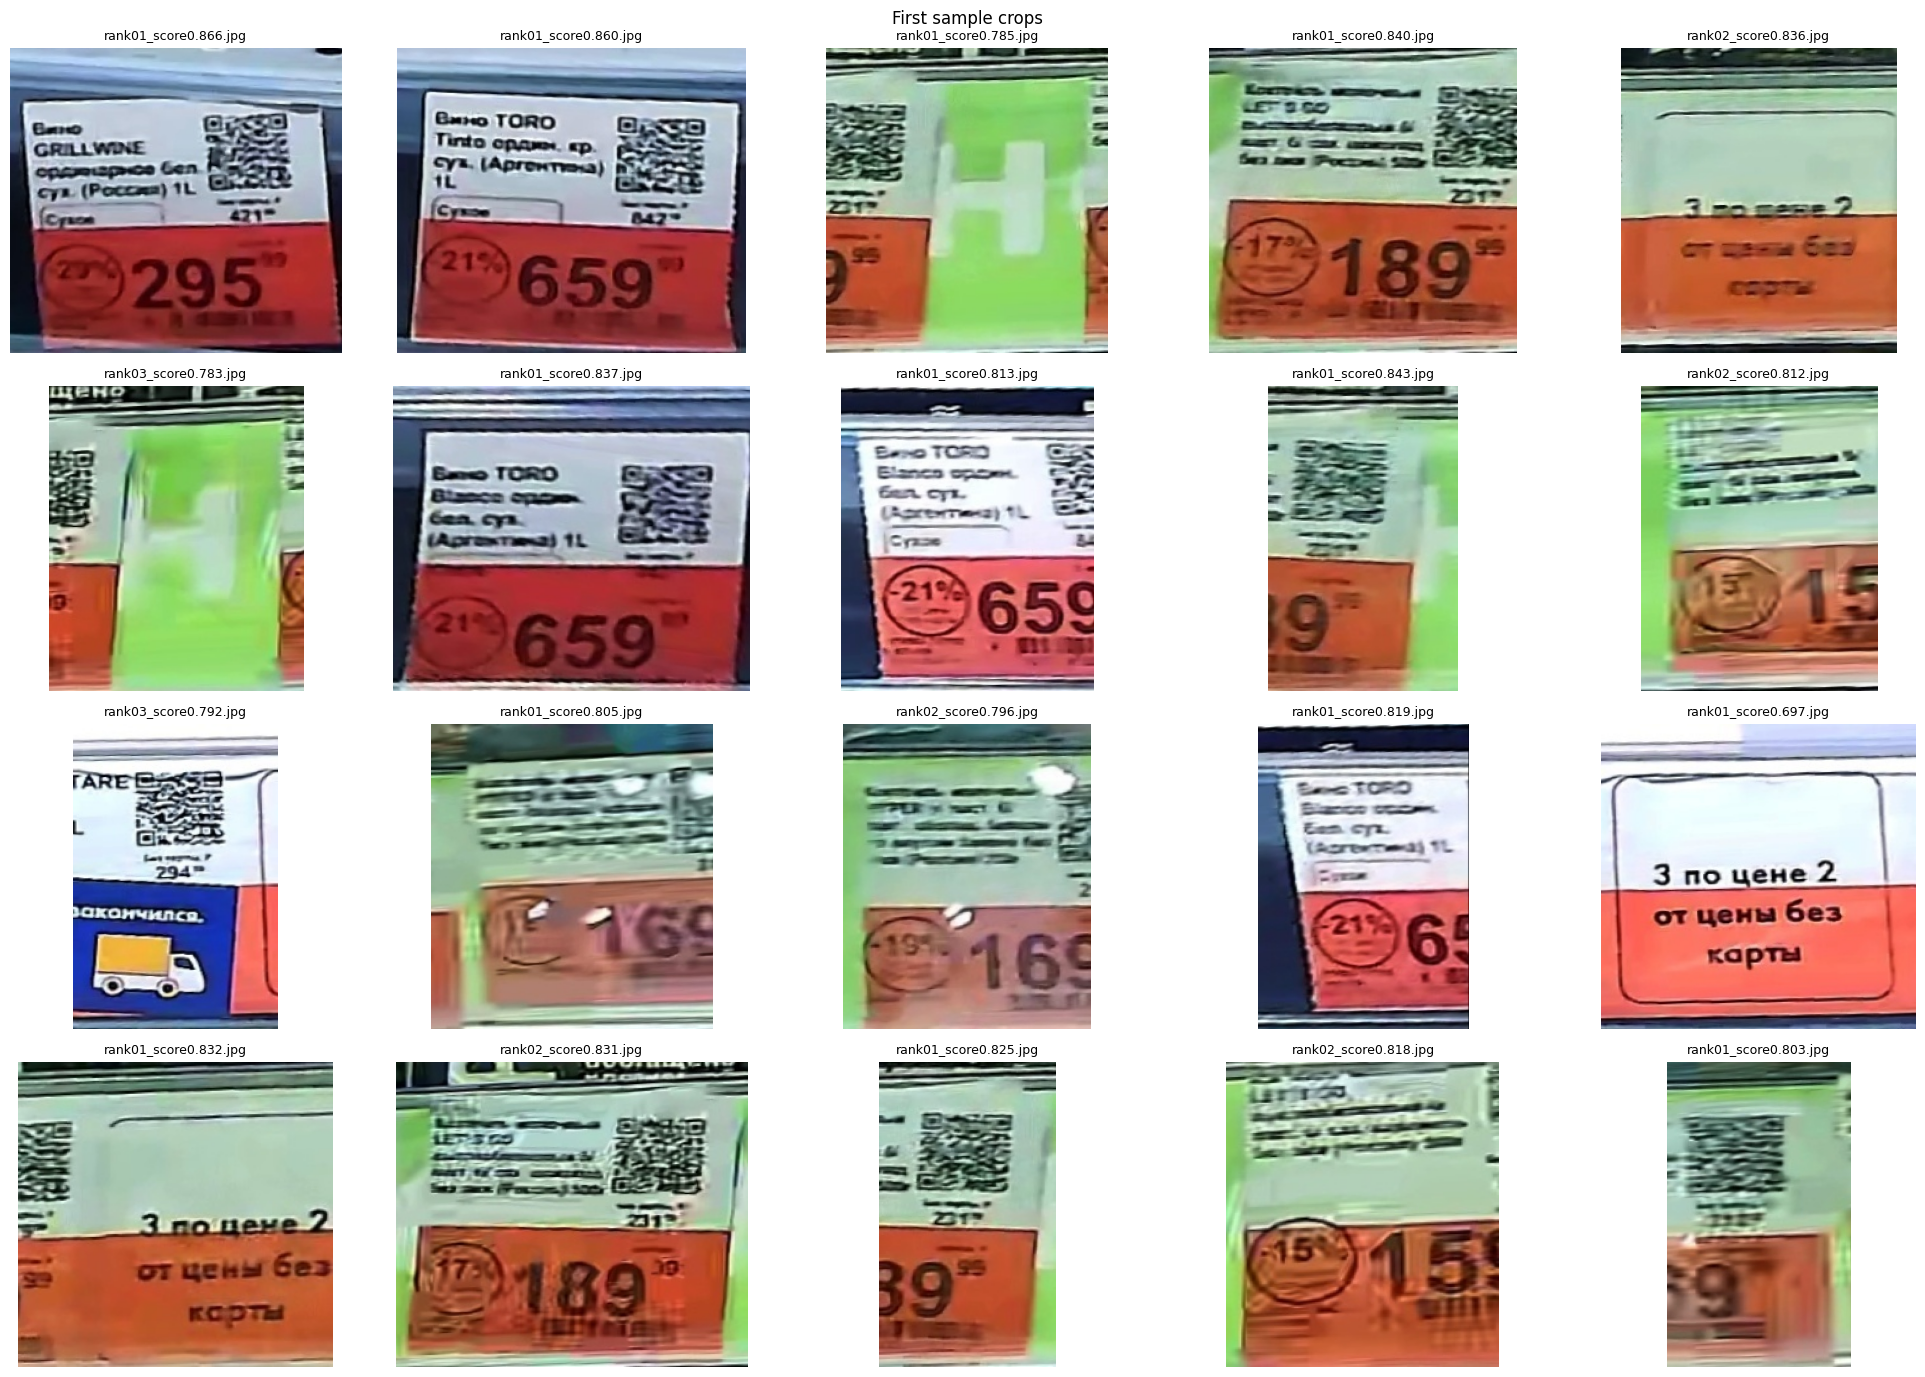

In [9]:
def show_image_grid(image_paths: list[Path], title: str = "Sample crops", max_n: int = 16, cols: int = 4) -> None:
    n = min(max_n, len(image_paths))
    if n == 0:
        print("No images to display")
        return

    rows = math.ceil(n / cols)
    plt.figure(figsize=(4 * cols, 3.5 * rows))

    for i in range(n):
        img = cv2.imread(str(image_paths[i]))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img_rgb)
        ax.set_title(image_paths[i].name, fontsize=9)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(all_images, title="First sample crops", max_n=20, cols=5)


## 5. Image variants

Готовим несколько вариантов одного изображения для устойчивости OCR/QR.


In [10]:
def ensure_bgr(image: np.ndarray) -> np.ndarray:
    if image is None:
        raise ValueError("Image is None")
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    return image


def make_variants(image_bgr: np.ndarray) -> dict[str, np.ndarray]:
    image_bgr = ensure_bgr(image_bgr)
    variants: dict[str, np.ndarray] = {}

    variants["original"] = image_bgr.copy()

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    variants["gray"] = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    h, w = image_bgr.shape[:2]
    variants["upscale_2x"] = cv2.resize(image_bgr, (w * 2, h * 2), interpolation=cv2.INTER_CUBIC)
    variants["upscale_4x"] = cv2.resize(image_bgr, (w * 4, h * 4), interpolation=cv2.INTER_CUBIC)

    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)).apply(l)
    lab_clahe = cv2.merge([clahe, a, b])
    variants["clahe"] = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    variants["sharpen"] = cv2.filter2D(image_bgr, ddepth=-1, kernel=kernel)

    th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 11)
    variants["adaptive_threshold"] = cv2.cvtColor(th, cv2.COLOR_GRAY2BGR)

    return variants


## 6. OCR

Запускаем OCR по вариантам изображения, собираем токены и делаем простую дедупликацию.


In [13]:
def normalize_whitespace(text: str) -> str:
    text = text.replace(" ", " ").replace(" ", " ").replace(" ", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalized_text_key(text: str) -> str:
    text = normalize_whitespace(text).lower()
    text = re.sub(r"[^0-9a-zа-яё%.,:/+\- ]+", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def bbox_from_quad(quad: Any) -> list[int]:
    pts = np.array(quad, dtype=float).reshape(-1, 2)
    x_min = int(np.min(pts[:, 0]))
    y_min = int(np.min(pts[:, 1]))
    x_max = int(np.max(pts[:, 0]))
    y_max = int(np.max(pts[:, 1]))
    return [x_min, y_min, x_max, y_max]


def _to_res_dict(item: Any) -> dict[str, Any]:
    if isinstance(item, dict):
        return item.get("res", item)
    if hasattr(item, "res"):
        return getattr(item, "res")
    if hasattr(item, "to_dict"):
        d = item.to_dict()
        return d.get("res", d) if isinstance(d, dict) else {}
    return {}


def run_paddle_ocr(image_bgr: np.ndarray, variant_name: str) -> list[dict[str, Any]]:
    if OCR_ENGINE is None:
        return []

    try:
        # PaddleOCR 3.x API
        pred = OCR_ENGINE.predict(image_bgr)
    except Exception as e:
        print(f"[WARN] OCR predict failed on {variant_name}: {e}")
        return []

    tokens: list[dict[str, Any]] = []
    if not pred:
        return tokens

    for item in pred:
        res = _to_res_dict(item)

        rec_texts = list(res.get("rec_texts", []) or [])
        rec_scores = list(res.get("rec_scores", []) or [])
        rec_boxes = res.get("rec_boxes", None)
        rec_polys = res.get("rec_polys", None)

        boxes: list[list[int]] = []
        if rec_boxes is not None and len(rec_boxes) > 0:
            arr = np.asarray(rec_boxes)
            if arr.ndim == 2 and arr.shape[1] == 4:
                boxes = [list(map(int, row.tolist())) for row in arr]
        elif rec_polys is not None and len(rec_polys) > 0:
            boxes = [bbox_from_quad(poly) for poly in rec_polys]

        for i, txt in enumerate(rec_texts):
            txt = normalize_whitespace(str(txt))
            if not txt:
                continue

            conf = float(rec_scores[i]) if i < len(rec_scores) else 0.0
            bbox = boxes[i] if i < len(boxes) else [0, 0, 0, 0]

            tokens.append(
                {
                    "text": txt,
                    "confidence": conf,
                    "bbox": bbox,
                    "variant": variant_name,
                }
            )

    return tokens


def deduplicate_tokens(tokens: list[dict[str, Any]]) -> list[dict[str, Any]]:
    best_by_key: dict[str, dict[str, Any]] = {}

    for tok in tokens:
        key = normalized_text_key(tok.get("text", ""))
        if not key:
            continue
        prev = best_by_key.get(key)
        if prev is None or tok.get("confidence", 0.0) > prev.get("confidence", 0.0):
            best_by_key[key] = tok

    deduped = list(best_by_key.values())
    deduped.sort(key=lambda t: (t["bbox"][1], t["bbox"][0]))
    return deduped


def run_ocr_on_image_variants(image_bgr: np.ndarray) -> dict[str, Any]:
    variants = make_variants(image_bgr)
    variants_for_ocr = ["original", "upscale_2x", "upscale_4x", "clahe", "sharpen"]

    all_tokens: list[dict[str, Any]] = []
    tokens_by_variant: dict[str, list[dict[str, Any]]] = {}

    for name in variants_for_ocr:
        vimg = variants.get(name)
        if vimg is None:
            continue
        vtoks = run_paddle_ocr(vimg, variant_name=name)
        tokens_by_variant[name] = vtoks
        all_tokens.extend(vtoks)

    dedup_tokens = deduplicate_tokens(all_tokens)

    return {
        "tokens": dedup_tokens,
        "tokens_all": all_tokens,
        "tokens_by_variant": tokens_by_variant,
        "ocr_backend": OCR_BACKEND_NAME if OCR_ENGINE is not None else "none",
    }


def visualize_ocr_boxes(image_bgr: np.ndarray, tokens: list[dict[str, Any]], title: str = "OCR boxes") -> np.ndarray:
    canvas = ensure_bgr(image_bgr).copy()
    for tok in tokens:
        x1, y1, x2, y2 = tok["bbox"]
        text = tok["text"]
        conf = tok.get("confidence", 0.0)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 220, 0), 2)
        cv2.putText(
            canvas,
            f"{text} ({conf:.2f})",
            (x1, max(15, y1 - 4)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 120, 255),
            1,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()
    return canvas


OCR backend: paddleocr
Dedup tokens: 21


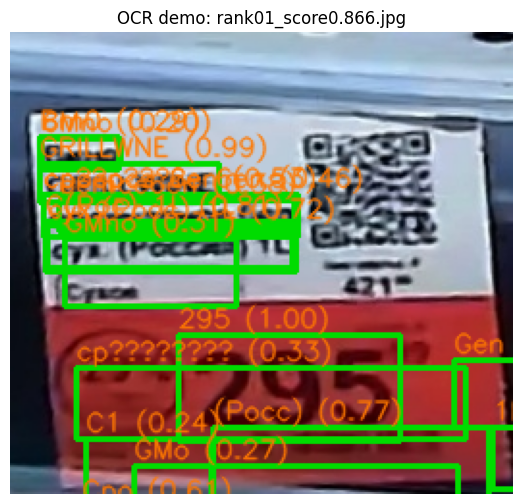

In [14]:
# Demo OCR visualization on one sample image
if all_images:
    demo_img_path = all_images[0]
    demo_img = cv2.imread(str(demo_img_path))
    demo_ocr = run_ocr_on_image_variants(demo_img)
    print("OCR backend:", demo_ocr["ocr_backend"])
    print("Dedup tokens:", len(demo_ocr["tokens"]))
    visualize_ocr_boxes(demo_img, demo_ocr["tokens"], title=f"OCR demo: {demo_img_path.name}")
else:
    print("No images found for OCR demo")


## 7. QR and barcode

Пробуем декодирование QR/штрихкода разными backend'ами, вариантами изображения и поворотами.


In [15]:
QR_FIELDS = [
    "qr_code_barcode",
    "price1_qr",
    "price2_qr",
    "price3_qr",
    "price4_qr",
    "wholesale_level_1_count",
    "wholesale_level_1_price",
    "wholesale_level_2_count",
    "wholesale_level_2_price",
    "action_price_qr",
    "action_code_qr",
]

QR_ALIASES = {
    "barcode": "qr_code_barcode",
    "b": "qr_code_barcode",
    "price1": "price1_qr",
    "p1": "price1_qr",
    "price2": "price2_qr",
    "p2": "price2_qr",
    "price3": "price3_qr",
    "p3": "price3_qr",
    "price4": "price4_qr",
    "p4": "price4_qr",
    "wholesalelevel1count": "wholesale_level_1_count",
    "wl1c": "wholesale_level_1_count",
    "wholesalelevel1price": "wholesale_level_1_price",
    "wl1p": "wholesale_level_1_price",
    "wholesalelevel2count": "wholesale_level_2_count",
    "wl2c": "wholesale_level_2_count",
    "wholesalelevel2price": "wholesale_level_2_price",
    "wl2p": "wholesale_level_2_price",
    "actionprice": "action_price_qr",
    "ap": "action_price_qr",
    "actioncode": "action_code_qr",
    "ac": "action_code_qr",
}


def rotate_image_90k(image_bgr: np.ndarray, k: int) -> np.ndarray:
    k = k % 4
    if k == 0:
        return image_bgr
    if k == 1:
        return cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    if k == 2:
        return cv2.rotate(image_bgr, cv2.ROTATE_180)
    return cv2.rotate(image_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)


def parse_qr_payload(qr_raw: str | None) -> dict[str, str]:
    result = {k: "" for k in QR_FIELDS}
    if not qr_raw:
        return result

    payload = qr_raw.strip()
    kv: dict[str, str] = {}

    # 1) JSON
    try:
        obj = json.loads(payload)
        if isinstance(obj, dict):
            for k, v in obj.items():
                kv[str(k)] = "" if v is None else str(v)
    except Exception:
        pass

    # 2) Query string style
    if not kv:
        q = payload
        parsed = urlparse(payload)
        if parsed.query:
            q = parsed.query
        q = q.replace(";", "&").replace("|", "&")
        for k, v in parse_qsl(q, keep_blank_values=True):
            kv[k] = v

    # 3) key=value chunks (fallback)
    if not kv and any(sep in payload for sep in ["=", ":"]):
        chunks = re.split(r"[&;|]", payload)
        for chunk in chunks:
            chunk = chunk.strip()
            if not chunk:
                continue
            if "=" in chunk:
                k, v = chunk.split("=", 1)
            elif ":" in chunk:
                k, v = chunk.split(":", 1)
            else:
                continue
            kv[k.strip()] = v.strip()

    # Map aliases
    for raw_k, v in kv.items():
        key_norm = re.sub(r"[^a-z0-9]", "", raw_k.lower())
        dst = QR_ALIASES.get(key_norm)
        if dst:
            result[dst] = str(v).strip()

    return result


def decode_qr_barcode(image_bgr: np.ndarray) -> dict[str, Any]:
    image_bgr = ensure_bgr(image_bgr)
    variants = make_variants(image_bgr)
    variant_names = ["original", "gray", "upscale_2x", "clahe", "adaptive_threshold"]

    qr_detector = cv2.QRCodeDetector()
    qr_candidates: list[tuple[str, str]] = []  # (backend, data)
    barcode_candidates: list[str] = []

    for vname in variant_names:
        base = variants.get(vname)
        if base is None:
            continue

        for k in range(4):
            rotated = rotate_image_90k(base, k)

            # OpenCV QR
            try:
                data, bbox, _ = qr_detector.detectAndDecode(rotated)
                if data:
                    qr_candidates.append(("opencv_qr", data))
            except Exception:
                pass

            # pyzbar (optional)
            if PYZBAR_AVAILABLE and pyzbar_decode is not None:
                try:
                    decoded = pyzbar_decode(rotated)
                    for obj in decoded:
                        raw = obj.data.decode("utf-8", errors="ignore").strip()
                        typ = str(obj.type).upper()
                        if not raw:
                            continue
                        if "QRCODE" in typ or typ == "QR_CODE":
                            qr_candidates.append(("pyzbar", raw))
                        else:
                            barcode_candidates.append(raw)
                except Exception:
                    pass

    # Dedup preserving order
    qr_unique = []
    seen_qr = set()
    for backend, raw in qr_candidates:
        key = raw.strip()
        if key and key not in seen_qr:
            seen_qr.add(key)
            qr_unique.append((backend, raw))

    bc_unique = []
    seen_bc = set()
    for b in barcode_candidates:
        bb = b.strip()
        if bb and bb not in seen_bc:
            seen_bc.add(bb)
            bc_unique.append(bb)

    qr_backend = None
    qr_raw = None
    if qr_unique:
        # MVP heuristic: choose the longest payload
        qr_backend, qr_raw = sorted(qr_unique, key=lambda x: len(x[1]), reverse=True)[0]

    return {
        "qr_raw": qr_raw,
        "barcodes": bc_unique,
        "qr_found": qr_raw is not None and qr_raw != "",
        "backend": qr_backend,
        "qr_all": [q for _, q in qr_unique],
    }


## 8. Basic color classifier and symbols

Классифицируем цвет ценника грубо по HSV и формируем `special_symbols` по OCR/QR сигналам.


In [16]:
def classify_color(image_bgr: np.ndarray) -> str:
    img = ensure_bgr(image_bgr)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Warm promo colors: red/orange/yellow
    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    red_mask = (((h <= 12) | (h >= 170)) & (s > 70) & (v > 60)).astype(np.uint8)
    orange_yellow_mask = (((h >= 13) & (h <= 35)) & (s > 60) & (v > 70)).astype(np.uint8)
    warm_ratio = float((red_mask.sum() + orange_yellow_mask.sum()) / red_mask.size)

    white_mask = ((s < 45) & (v > 180)).astype(np.uint8)
    white_ratio = float(white_mask.sum() / white_mask.size)

    if warm_ratio > 0.18:
        return "promo"
    if white_ratio > 0.65:
        return "white"
    return "other"


def infer_special_symbols(tokens: list[dict[str, Any]], qr_info: dict[str, Any]) -> str:
    txt = " ".join([t.get("text", "") for t in tokens]).lower()
    symbols: list[str] = []

    if qr_info.get("qr_found"):
        symbols.append("qr")
    if qr_info.get("barcodes"):
        symbols.append("barcode")

    if re.search(r"\d+\s*%", txt) or any(k in txt for k in ["скид", "акци", "выгод"]):
        symbols.append("discount_percent")

    if any(k in txt for k in ["карта", "по карте", "card"]):
        symbols.append("card_price")

    if not symbols:
        symbols.append("standard")

    # unique preserving order
    dedup = []
    seen = set()
    for s in symbols:
        if s not in seen:
            dedup.append(s)
            seen.add(s)

    return "; ".join(dedup)


## 9. Parsers

Regex + эвристики для извлечения полей из OCR токенов.


In [17]:
def token_texts(tokens: list[dict[str, Any]]) -> list[str]:
    return [normalize_whitespace(str(t.get("text", ""))) for t in tokens if str(t.get("text", "")).strip()]


def joined_text(tokens: list[dict[str, Any]]) -> str:
    return "\n".join(token_texts(tokens))


def looks_like_price_text(text: str) -> bool:
    text = normalize_whitespace(text)
    if re.search(r"\d+[\s.,]\d{2}", text):
        return True
    if re.fullmatch(r"\d{4,6}", re.sub(r"\s+", "", text)):
        return True
    return False


def normalize_price_candidate(raw: str) -> str | None:
    s = normalize_whitespace(raw)
    s = s.replace(",", ".")

    # Case: 1 029 99 or 295 99
    if re.fullmatch(r"\d{1,3}(?:\s\d{3})*\s\d{2}", s):
        parts = s.split()
        int_part = "".join(parts[:-1])
        dec_part = parts[-1]
        int_part = int_part.lstrip("0") or "0"
        return f"{int_part}.{dec_part}"

    # Case: with decimal separator already
    if re.fullmatch(r"\d{1,3}(?:\s\d{3})*(?:\.\d{2})", s):
        whole, dec = s.split(".")
        whole = whole.replace(" ", "")
        whole = whole.lstrip("0") or "0"
        return f"{whole}.{dec}"

    # Case: compact integer where last 2 digits are decimals, e.g. 29599
    compact = re.sub(r"\s+", "", s)
    if re.fullmatch(r"\d{4,6}", compact):
        int_part = compact[:-2].lstrip("0") or "0"
        dec_part = compact[-2:]
        return f"{int_part}.{dec_part}"

    return None


def extract_price_candidates(tokens: list[dict[str, Any]]) -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []

    pat = re.compile(r"\d{1,3}(?:\s\d{3})*\s\d{2}|\d{1,3}(?:\s\d{3})*[.,]\d{2}|\d{4,6}")

    for tok in tokens:
        txt = normalize_whitespace(tok.get("text", ""))
        if not txt:
            continue
        for m in pat.finditer(txt):
            raw = m.group(0)
            price = normalize_price_candidate(raw)
            if not price:
                continue
            x1, y1, x2, y2 = tok.get("bbox", [0, 0, 0, 0])
            area = max(1, (x2 - x1) * (y2 - y1))
            candidates.append(
                {
                    "raw": raw,
                    "price": price,
                    "confidence": float(tok.get("confidence", 0.0)),
                    "bbox": tok.get("bbox", [0, 0, 0, 0]),
                    "area": area,
                    "source_text": txt,
                }
            )

    # Dedup by normalized price, keep highest confidence*area
    best = {}
    for c in candidates:
        k = c["price"]
        prev = best.get(k)
        score = c["confidence"] * math.log(max(2, c["area"]))
        if prev is None:
            best[k] = c
        else:
            pscore = prev["confidence"] * math.log(max(2, prev["area"]))
            if score > pscore:
                best[k] = c

    return list(best.values())


def parse_product_name(tokens: list[dict[str, Any]]) -> str:
    candidates: list[tuple[int, float, str]] = []

    for tok in tokens:
        text = normalize_whitespace(tok.get("text", ""))
        if len(text) < 3:
            continue
        low = text.lower()

        # Must contain letters
        if not re.search(r"[a-zа-яё]", low, flags=re.IGNORECASE):
            continue

        # Exclusions: obvious non-name lines
        if looks_like_price_text(text):
            continue
        if re.search(r"\d{2}[./-]\d{2}[./-]\d{2,4}", text):
            continue
        if re.search(r"(?:арт|артикул|sku|код товара|код зоны|barcode|штрих)", low):
            continue
        if len(re.sub(r"\D", "", text)) >= 8:
            continue

        bbox = tok.get("bbox", [0, 0, 0, 0])
        y = bbox[1] if len(bbox) == 4 else 9999
        conf = float(tok.get("confidence", 0.0))
        candidates.append((y, conf, text))

    if not candidates:
        return ""

    candidates.sort(key=lambda x: (x[0], -x[1]))

    selected = []
    seen = set()
    for _, _, txt in candidates:
        key = normalized_text_key(txt)
        if key in seen:
            continue
        selected.append(txt)
        seen.add(key)
        if len(selected) >= 4:
            break

    return " ".join(selected).strip()


def parse_prices(tokens: list[dict[str, Any]], color: str, special_symbols: str) -> dict[str, str]:
    result = {
        "price_default": "",
        "price_card": "",
        "price_discount": "",
    }

    price_cands = extract_price_candidates(tokens)
    if not price_cands:
        return result

    txt = joined_text(tokens).lower()
    has_promo = (color == "promo") or ("discount_percent" in special_symbols) or any(k in txt for k in ["акц", "скид", "%"])
    has_card = ("card_price" in special_symbols) or any(k in txt for k in ["карта", "по карте", "card"])

    # Sort by numeric value for simple heuristics
    numeric = []
    for c in price_cands:
        try:
            numeric.append((float(c["price"]), c))
        except Exception:
            pass
    numeric.sort(key=lambda x: x[0])

    # Main candidate by visual prominence + confidence
    main = sorted(
        price_cands,
        key=lambda c: c["confidence"] * math.log(max(2, c["area"])),
        reverse=True,
    )[0]

    if len(price_cands) == 1:
        one = price_cands[0]["price"]
        if has_promo:
            result["price_discount"] = one
            result["price_default"] = "нет"
            result["price_card"] = "нет"
        else:
            result["price_default"] = one
            result["price_discount"] = "нет"
            result["price_card"] = "нет"
        return result

    # Multiple prices
    min_price = numeric[0][1]["price"] if numeric else main["price"]
    max_price = numeric[-1][1]["price"] if numeric else main["price"]

    if has_card and has_promo:
        result["price_card"] = min_price
        result["price_default"] = max_price
        if len(numeric) >= 3:
            result["price_discount"] = numeric[1][1]["price"]
        else:
            result["price_discount"] = min_price
    elif has_card:
        result["price_card"] = min_price
        result["price_default"] = max_price
        result["price_discount"] = "нет"
    elif has_promo:
        result["price_discount"] = min_price
        result["price_default"] = max_price
        result["price_card"] = "нет"
    else:
        result["price_default"] = main["price"]
        result["price_card"] = "нет"
        result["price_discount"] = "нет"

    return result


def parse_barcode(tokens: list[dict[str, Any]], decoded_barcodes: list[str]) -> str:
    candidates: list[str] = []

    # Prefer decoder outputs first
    for b in decoded_barcodes:
        b = str(b).strip()
        if not b:
            continue
        digits = re.sub(r"\D", "", b)
        candidates.append(digits if digits else b)

    # OCR fallback
    for t in token_texts(tokens):
        for m in re.finditer(r"\d{6,}", re.sub(r"\s+", "", t)):
            candidates.append(m.group(0))

    if not candidates:
        return ""

    candidates = [c for c in candidates if c]
    candidates.sort(key=lambda x: (len(x), x), reverse=True)
    return candidates[0]


def parse_discount_amount(tokens: list[dict[str, Any]]) -> str:
    txt = joined_text(tokens).lower()

    m = re.search(r"-?\s*(\d{1,2})\s*%", txt)
    if m:
        return f"{m.group(1)}%"

    m = re.search(r"(?:скидка|выгода)\s*-?\s*(\d{1,2})", txt)
    if m:
        return f"{m.group(1)}%"

    if any(k in txt for k in ["скид", "акци", "%", "выгод"]):
        return ""

    return "нет"


def parse_print_datetime(tokens: list[dict[str, Any]]) -> str:
    txt = joined_text(tokens)
    patterns = [
        r"\d{2}\.\d{2}\.\d{4}\s+\d{2}:\d{2}",
        r"\d{2}\.\d{2}\.\d{2}\s+\d{2}:\d{2}",
        r"\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}",
        r"\d{2}/\d{2}/\d{4}\s+\d{2}:\d{2}",
    ]
    for p in patterns:
        m = re.search(p, txt)
        if m:
            return m.group(0)
    return ""


def parse_sku(tokens: list[dict[str, Any]]) -> str:
    txt = joined_text(tokens)

    m = re.search(
        r"(?:арт\.?|артикул|sku|код\s*товара)\s*[:#-]?\s*([A-Za-zА-Яа-я0-9\-_/]{3,})",
        txt,
        flags=re.IGNORECASE,
    )
    if m:
        return m.group(1)

    return ""


def parse_code(tokens: list[dict[str, Any]]) -> str:
    txt = joined_text(tokens)

    m = re.search(
        r"(?:код\s*зоны|зона|code|код)\s*[:#-]?\s*([A-Za-zА-Яа-я0-9\-_/]{2,})",
        txt,
        flags=re.IGNORECASE,
    )
    if m:
        return m.group(1)

    return ""


def parse_additional_info(tokens: list[dict[str, Any]], used_texts: set[str]) -> str:
    leftovers = []
    seen = set()

    for tok in tokens:
        txt = normalize_whitespace(tok.get("text", ""))
        if not txt:
            continue
        key = normalized_text_key(txt)
        if not key or key in used_texts:
            continue
        if len(txt) < 3:
            continue

        # Skip pure numeric garbage
        if re.fullmatch(r"[\d\s.,:%+-]+", txt):
            continue

        if key not in seen:
            leftovers.append(txt)
            seen.add(key)

    if not leftovers:
        return "нет"

    return "; ".join(leftovers)


## 10. Process one image

Формируем полный результат по одной картинке: OCR, QR/barcode, парсинг и debug-структуры.


In [18]:
def process_one_image(image_path: Path) -> dict[str, Any]:
    out: dict[str, Any] = {
        "image_path": str(image_path),
        "ocr_tokens": [],
        "qr": {},
        "parsed": {},
        "quality": {},
        "debug": {},
        "error": None,
    }

    try:
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Cannot read image: {image_path}")

        h, w = image.shape[:2]

        ocr_result = run_ocr_on_image_variants(image)
        tokens = ocr_result["tokens"]

        qr_result = decode_qr_barcode(image)
        qr_fields = parse_qr_payload(qr_result.get("qr_raw"))

        color = classify_color(image)
        special_symbols = infer_special_symbols(tokens, qr_result)

        product_name = parse_product_name(tokens)
        price_fields = parse_prices(tokens, color=color, special_symbols=special_symbols)
        barcode_value = parse_barcode(tokens, qr_result.get("barcodes", []))
        discount_amount = parse_discount_amount(tokens)
        print_datetime = parse_print_datetime(tokens)
        sku = parse_sku(tokens)
        code_zone = parse_code(tokens)

        used_texts = set()
        if product_name:
            for part in product_name.split(" "):
                if part.strip():
                    used_texts.add(normalized_text_key(part))

        additional_info = parse_additional_info(tokens, used_texts)

        parsed = {
            "product_name": product_name,
            "price_default": price_fields["price_default"],
            "price_card": price_fields["price_card"],
            "price_discount": price_fields["price_discount"],
            "barcode": barcode_value,
            "discount_amount": discount_amount,
            "id_sku": sku,
            "print_datetime": print_datetime,
            "code": code_zone,
            "additional_info": additional_info,
            "color": color,
            "special_symbols": special_symbols,
            "frame_timestamp": "нет",
            "x_min": 0,
            "y_min": 0,
            "x_max": int(w),
            "y_max": int(h),
            **qr_fields,
        }

        out["ocr_tokens"] = tokens
        out["qr"] = {**qr_result, "parsed_fields": qr_fields}
        out["parsed"] = parsed
        out["quality"] = {
            "width": int(w),
            "height": int(h),
            "ocr_tokens_count": len(tokens),
            "ocr_avg_conf": float(np.mean([t.get("confidence", 0.0) for t in tokens])) if tokens else 0.0,
        }
        out["debug"] = {
            "ocr_tokens_all": ocr_result.get("tokens_all", []),
            "ocr_tokens_by_variant": ocr_result.get("tokens_by_variant", {}),
            "ocr_backend": ocr_result.get("ocr_backend", "none"),
        }

    except Exception as exc:
        out["error"] = f"{type(exc).__name__}: {exc}"
        out["debug"]["traceback"] = traceback.format_exc()

    return out


## 11. Merge results inside one track

Одна папка `track_*` = одна финальная строка CSV.


In [19]:
OUTPUT_COLUMNS = [
    "filename",
    "product_name",
    "price_default",
    "price_card",
    "price_discount",
    "barcode",
    "discount_amount",
    "id_sku",
    "print_datetime",
    "code",
    "additional_info",
    "color",
    "special_symbols",
    "frame_timestamp",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
    "qr_code_barcode",
    "price1_qr",
    "price2_qr",
    "price3_qr",
    "price4_qr",
    "wholesale_level_1_count",
    "wholesale_level_1_price",
    "wholesale_level_2_count",
    "wholesale_level_2_price",
    "action_price_qr",
    "action_code_qr",
]


def is_non_empty(v: Any) -> bool:
    return v is not None and str(v).strip() != ""


def choose_mode(values: list[str]) -> str:
    vals = [str(v).strip() for v in values if is_non_empty(v)]
    if not vals:
        return ""
    cnt = Counter(vals)
    best_count = max(cnt.values())
    best = [k for k, c in cnt.items() if c == best_count]
    # Tie-breaker: prefer longer non-empty value
    best.sort(key=lambda x: (len(x), x), reverse=True)
    return best[0]


def choose_best_price(values: list[str]) -> str:
    vals = [str(v).strip() for v in values if is_non_empty(v)]
    if not vals:
        return ""

    cnt = Counter(vals)
    top_freq = max(cnt.values())
    top_vals = [k for k, c in cnt.items() if c == top_freq]

    # If tie: prefer valid price format and higher precision (295.99 over 295.9)
    def key_fn(v: str):
        is_valid = bool(re.fullmatch(r"\d+\.\d{1,2}", v))
        precision = len(v.split(".")[1]) if "." in v else 0
        return (1 if is_valid else 0, precision, len(v), v)

    top_vals.sort(key=key_fn, reverse=True)
    return top_vals[0]


def choose_barcode(candidates: list[str]) -> str:
    vals = [str(v).strip() for v in candidates if is_non_empty(v)]
    if not vals:
        return ""
    vals.sort(key=lambda x: (len(re.sub(r"\D", "", x)), len(x), x), reverse=True)
    return vals[0]


def merge_track_results(track_dir: Path, image_results: list[dict[str, Any]]) -> dict[str, Any]:
    parsed_list = [r.get("parsed", {}) for r in image_results if r.get("parsed")]

    warnings = []
    errors = [r.get("error") for r in image_results if r.get("error")]
    if errors:
        warnings.extend(errors)

    # Coordinates from rank01 if possible, else from the first valid image
    chosen_image = None
    rank01_candidates = sorted(track_dir.glob("rank01_*.jpg"))
    if rank01_candidates:
        chosen_image = rank01_candidates[0]
    else:
        imgs = sorted([p for p in track_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])
        if imgs:
            chosen_image = imgs[0]

    x_max = y_max = 0
    if chosen_image is not None:
        img = cv2.imread(str(chosen_image))
        if img is not None:
            h, w = img.shape[:2]
            x_max = int(w)
            y_max = int(h)

    # Product name: longest meaningful option
    product_candidates = [p.get("product_name", "") for p in parsed_list if is_non_empty(p.get("product_name", ""))]
    product_candidates = [v for v in product_candidates if re.search(r"[a-zа-яё]", v, flags=re.IGNORECASE)]
    product_name = ""
    if product_candidates:
        product_candidates.sort(key=lambda s: (len(s), s), reverse=True)
        product_name = product_candidates[0]

    # Prices
    price_default = choose_best_price([p.get("price_default", "") for p in parsed_list])
    price_card = choose_best_price([p.get("price_card", "") for p in parsed_list])
    price_discount = choose_best_price([p.get("price_discount", "") for p in parsed_list])

    # Preserve explicit "нет" when no concrete value but there is consensus absence
    if not price_default and any(p.get("price_default") == "нет" for p in parsed_list):
        price_default = "нет"
    if not price_card and any(p.get("price_card") == "нет" for p in parsed_list):
        price_card = "нет"
    if not price_discount and any(p.get("price_discount") == "нет" for p in parsed_list):
        price_discount = "нет"

    # Barcode: OCR + decoded barcode + QR barcode
    barcode_candidates = [p.get("barcode", "") for p in parsed_list]
    qr_barcode_candidates = [p.get("qr_code_barcode", "") for p in parsed_list if is_non_empty(p.get("qr_code_barcode", ""))]
    merged_barcode = choose_barcode(barcode_candidates)
    qr_barcode = choose_barcode(qr_barcode_candidates)

    if qr_barcode and (not merged_barcode or len(qr_barcode) >= len(merged_barcode)):
        merged_barcode = qr_barcode

    discount_amount = choose_mode([p.get("discount_amount", "") for p in parsed_list])
    print_datetime = choose_mode([p.get("print_datetime", "") for p in parsed_list])
    id_sku = choose_mode([p.get("id_sku", "") for p in parsed_list])
    code_val = choose_mode([p.get("code", "") for p in parsed_list])

    color = choose_mode([p.get("color", "") for p in parsed_list]) or "other"

    # special_symbols: union
    sym_set = []
    seen = set()
    for p in parsed_list:
        raw = str(p.get("special_symbols", "")).strip()
        if not raw:
            continue
        for s in [x.strip() for x in raw.split(";") if x.strip()]:
            if s not in seen:
                seen.add(s)
                sym_set.append(s)
    special_symbols = "; ".join(sym_set) if sym_set else "standard"

    # additional_info: unique join
    add_parts = []
    seen_add = set()
    for p in parsed_list:
        raw = str(p.get("additional_info", "")).strip()
        if not raw or raw == "нет":
            continue
        for s in [x.strip() for x in raw.split(";") if x.strip()]:
            key = normalized_text_key(s)
            if key and key not in seen_add:
                seen_add.add(key)
                add_parts.append(s)
    additional_info = "; ".join(add_parts) if add_parts else "нет"

    # QR fields: fill from first parsed QR with any values
    qr_merged = {k: "нет" for k in QR_FIELDS}
    qr_found_any = False
    for p in parsed_list:
        has_any = any(is_non_empty(p.get(k, "")) for k in QR_FIELDS)
        if has_any:
            qr_found_any = True
            for k in QR_FIELDS:
                if is_non_empty(p.get(k, "")):
                    qr_merged[k] = str(p[k]).strip()
            break

    if not qr_found_any:
        qr_merged = {k: "нет" for k in QR_FIELDS}

    row = {
        "filename": track_dir.name,
        "product_name": product_name,
        "price_default": price_default,
        "price_card": price_card,
        "price_discount": price_discount,
        "barcode": merged_barcode,
        "discount_amount": discount_amount,
        "id_sku": id_sku,
        "print_datetime": print_datetime,
        "code": code_val,
        "additional_info": additional_info,
        "color": color,
        "special_symbols": special_symbols,
        "frame_timestamp": "нет",
        "x_min": 0,
        "y_min": 0,
        "x_max": x_max,
        "y_max": y_max,
        **qr_merged,
    }

    # Ensure all required columns are present
    for col in OUTPUT_COLUMNS:
        if col not in row:
            row[col] = ""

    return {
        "row": row,
        "warnings": warnings,
        "errors": errors,
        "qr_found": qr_found_any,
    }


## 12. Process all tracks

Итерируем по `track_*`, не падаем на отдельных ошибках, сохраняем debug JSON и debug-изображения.


In [ ]:
def serialize_for_json(obj: Any) -> Any:
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(f"Type not serializable: {type(obj)}")


rows: list[dict[str, Any]] = []
track_debug_summary: list[dict[str, Any]] = []
MAX_DEBUG_IMAGES = 12

for i, track_dir in enumerate(tqdm(TRACK_DIRS, desc="Processing tracks")):
    image_paths = sorted([p for p in track_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])

    image_results: list[dict[str, Any]] = []
    warnings: list[str] = []

    for image_path in image_paths:
        try:
            res = process_one_image(image_path)
            image_results.append(res)
            if res.get("error"):
                warnings.append(res["error"])
        except Exception as exc:
            warnings.append(f"Unhandled image error: {type(exc).__name__}: {exc}")

    merged = merge_track_results(track_dir, image_results)
    row = merged["row"]
    rows.append(row)

    # Track-level debug JSON
    debug_payload = {
        "track": track_dir.name,
        "images": [str(p) for p in image_paths],
        "image_results": image_results,
        "merged_final_fields": row,
        "warnings": warnings + merged.get("warnings", []),
        "errors": merged.get("errors", []),
    }

    debug_json_path = DEBUG_DIR / f"{track_dir.name}.json"
    with debug_json_path.open("w", encoding="utf-8") as f:
        json.dump(debug_payload, f, ensure_ascii=False, indent=2, default=serialize_for_json)

    # Save OCR box debug images for first N tracks
    if i < MAX_DEBUG_IMAGES and image_results:
        # Prefer image with most OCR tokens
        valid = [r for r in image_results if r.get("ocr_tokens")]
        if valid:
            best = sorted(valid, key=lambda r: len(r.get("ocr_tokens", [])), reverse=True)[0]
            img_path = Path(best["image_path"])
            img = cv2.imread(str(img_path))
            if img is not None:
                vis = img.copy()
                for tok in best.get("ocr_tokens", []):
                    x1, y1, x2, y2 = tok.get("bbox", [0, 0, 0, 0])
                    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 220, 0), 2)
                dbg_img_path = DEBUG_DIR / f"{track_dir.name}_ocr_boxes.jpg"
                cv2.imwrite(str(dbg_img_path), vis)

    track_debug_summary.append(
        {
            "track": track_dir.name,
            "images": len(image_paths),
            "warnings": len(warnings),
            "qr_found": merged.get("qr_found", False),
        }
    )

print("Done. Rows prepared:", len(rows))


Processing tracks:   0%|          | 0/312 [00:00<?, ?it/s]

## 13. Save outputs

Собираем DataFrame, контролируем порядок колонок и сохраняем CSV.


In [ ]:
result_df = pd.DataFrame(rows)

# Remove accidental duplicate columns (if any)
result_df = result_df.loc[:, ~result_df.columns.duplicated()]

# Reindex strictly by required output schema
for col in OUTPUT_COLUMNS:
    if col not in result_df.columns:
        result_df[col] = ""
result_df = result_df[OUTPUT_COLUMNS]

result_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"Saved CSV: {OUTPUT_CSV}")
print(f"Debug JSON dir: {DEBUG_DIR}")


## 14. Summary

Считаем базовые метрики заполнения и показываем первые строки результата.


In [ ]:
def non_empty_and_not_net(series: pd.Series) -> int:
    return int(((series.fillna("").astype(str).str.strip() != "") & (series.fillna("").astype(str).str.strip() != "нет")).sum())

tracks_processed = len(result_df)
product_name_filled = non_empty_and_not_net(result_df["product_name"])
price_default_filled = non_empty_and_not_net(result_df["price_default"])
price_discount_filled = non_empty_and_not_net(result_df["price_discount"])
barcode_filled = non_empty_and_not_net(result_df["barcode"])
qr_detected = non_empty_and_not_net(result_df["qr_code_barcode"])

print("Tracks processed:", tracks_processed)
print("product_name filled:", product_name_filled)
print("price_default filled:", price_default_filled)
print("price_discount filled:", price_discount_filled)
print("barcode filled:", barcode_filled)
print("QR detected:", qr_detected)

display(result_df.head(20))


## 15. Optional evaluation

Если появится GT CSV, можно включить этот блок. По умолчанию `GT_CSV = None`.


In [ ]:
from difflib import SequenceMatcher

GT_CSV = None  # Example: PROJECT_ROOT / "ground_truth.csv"

if GT_CSV is None:
    print("GT_CSV is None -> evaluation skipped")
else:
    gt_path = Path(GT_CSV)
    if not gt_path.exists():
        print(f"GT CSV not found: {gt_path}")
    else:
        gt_df = pd.read_csv(gt_path)

        if "filename" not in gt_df.columns:
            raise ValueError("GT CSV must contain 'filename' column")

        pred = result_df.copy()
        merged = gt_df.merge(pred, on="filename", suffixes=("_gt", "_pred"), how="inner")
        print("Matched rows:", len(merged))

        def exact_rate(col: str) -> float:
            c1 = f"{col}_gt"
            c2 = f"{col}_pred"
            if c1 not in merged.columns or c2 not in merged.columns or len(merged) == 0:
                return float("nan")
            return float((merged[c1].fillna("").astype(str).str.strip() == merged[c2].fillna("").astype(str).str.strip()).mean())

        def fuzzy_name_rate() -> float:
            c1 = "product_name_gt"
            c2 = "product_name_pred"
            if c1 not in merged.columns or c2 not in merged.columns or len(merged) == 0:
                return float("nan")
            vals = []
            for a, b in zip(merged[c1].fillna(""), merged[c2].fillna("")):
                vals.append(SequenceMatcher(None, str(a), str(b)).ratio())
            return float(np.mean(vals)) if vals else float("nan")

        def partial_barcode_rate() -> float:
            c1 = "barcode_gt"
            c2 = "barcode_pred"
            if c1 not in merged.columns or c2 not in merged.columns or len(merged) == 0:
                return float("nan")
            ok = []
            for a, b in zip(merged[c1].fillna(""), merged[c2].fillna("")):
                a = re.sub(r"\D", "", str(a))
                b = re.sub(r"\D", "", str(b))
                if not a and not b:
                    ok.append(1)
                elif a and b and (a in b or b in a):
                    ok.append(1)
                else:
                    ok.append(0)
            return float(np.mean(ok)) if ok else float("nan")

        print("Exact price_default:", exact_rate("price_default"))
        print("Exact price_card:", exact_rate("price_card"))
        print("Exact price_discount:", exact_rate("price_discount"))
        print("Fuzzy product_name:", fuzzy_name_rate())
        print("Partial barcode match:", partial_barcode_rate())

        fill_rate = {}
        for col in OUTPUT_COLUMNS:
            val = ((pred[col].fillna("").astype(str).str.strip() != "") & (pred[col].fillna("").astype(str).str.strip() != "нет")).mean()
            fill_rate[col] = float(val)

        fill_rate_df = pd.DataFrame({"field": list(fill_rate.keys()), "fill_rate": list(fill_rate.values())})
        display(fill_rate_df.sort_values("fill_rate", ascending=False))
